<a href="https://www.kaggle.com/code/lalit7881/spotify-hits-insights?scriptVersionId=305500844" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/emanfatima2/spotify-global-hits-and-artist-analytics/spotify_wrapped_2025_top50_artists.csv
/kaggle/input/datasets/emanfatima2/spotify-global-hits-and-artist-analytics/spotify_wrapped_2025_top50_songs.csv
/kaggle/input/datasets/emanfatima2/spotify-global-hits-and-artist-analytics/spotify_alltime_top100_songs.csv


## Loading dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/emanfatima2/spotify-global-hits-and-artist-analytics/spotify_alltime_top100_songs.csv')
df.head(10)

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100
5,6,Stay,The Kid LAROI & Justin Bieber,3.87,Pop,170,2021,Australia,True,0.59,0.80,0.60,0.00,Spotify All-Time Most Streamed Top 100
6,7,Believer,Imagine Dragons,3.76,Alt Rock,125,2017,USA,False,0.33,0.86,0.45,0.07,Spotify All-Time Most Streamed Top 100
7,8,Rockstar,Post Malone ft. 21 Savage,3.72,Hip-Hop,159,2017,USA,True,0.55,0.52,0.13,0.08,Spotify All-Time Most Streamed Top 100
8,9,Dance Monkey,Tones and I,3.69,Pop,98,2019,Australia,False,0.83,0.63,0.73,0.14,Spotify All-Time Most Streamed Top 100
9,10,Happier,Marshmello & Bastille,3.65,EDM/Pop,100,2018,USA/UK,False,0.62,0.82,0.96,0.02,Spotify All-Time Most Streamed Top 100


In [3]:
df.tail()

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
95,96,Electricity,Silk City & Dua Lipa,1.92,EDM/Pop,143,2018,UK,False,0.76,0.88,0.72,0.00,Spotify All-Time Most Streamed Top 100
96,97,Blinding Lights (Remix),The Weeknd & Rosalía,1.44,Synth-Pop,171,2020,Canada/Spain,False,0.54,0.80,0.36,0.01,Spotify All-Time Most Streamed Top 100
97,98,Falling For You,Peachy feat. mxmtoon,1.56,Indie Pop,150,2018,USA,False,0.64,0.42,0.72,0.38,Spotify All-Time Most Streamed Top 100
98,99,Laugh Now Cry Later,Drake ft. Lil Durk,3.05,Hip-Hop,142,2020,Canada,True,0.82,0.62,0.55,0.02,Spotify All-Time Most Streamed Top 100
99,100,Shake It Off,Taylor Swift,1.60,Pop,160,2014,USA,False,0.65,0.80,0.94,0.06,Spotify All-Time Most Streamed Top 100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   alltime_rank            100 non-null    int64  
 1   song_title              100 non-null    object 
 2   artist                  100 non-null    object 
 3   total_streams_billions  100 non-null    float64
 4   primary_genre           100 non-null    object 
 5   bpm                     100 non-null    int64  
 6   release_year            100 non-null    int64  
 7   artist_country          100 non-null    object 
 8   explicit                100 non-null    bool   
 9   danceability            100 non-null    float64
 10  energy                  100 non-null    float64
 11  valence                 100 non-null    float64
 12  acousticness            100 non-null    float64
 13  dataset_part            100 non-null    object 
dtypes: bool(1), float64(5), int64(3), object(5)

In [5]:
df.describe()

,alltime_rank,total_streams_billions,bpm,release_year,danceability,energy,valence,acousticness
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,2.524600,115.780000,2016.800000,0.613500,0.636100,0.550600,0.153400
std,29.011492,0.851432,30.540776,7.063922,0.142888,0.163824,0.238623,0.164637
min,1.000000,1.400000,62.000000,1985.000000,0.300000,0.260000,0.070000,0.000000
25%,25.750000,1.735000,95.000000,2016.000000,0.520000,0.527500,0.387500,0.020000
50%,50.500000,2.435000,107.000000,2018.500000,0.620000,0.650000,0.565000,0.085000
75%,75.250000,3.167500,139.000000,2021.000000,0.725000,0.775000,0.732500,0.245000
max,100.000000,5.260000,191.000000,2024.000000,0.900000,0.960000,0.960000,0.760000


In [6]:
df.dtypes

alltime_rank                int64
song_title                 object
artist                     object
total_streams_billions    float64
primary_genre              object
bpm                         int64
release_year                int64
artist_country             object
explicit                     bool
danceability              float64
energy                    float64
valence                   float64
acousticness              float64
dataset_part               object
dtype: object

In [7]:
df.shape

(100, 14)

In [8]:
df.columns

Index(['alltime_rank', 'song_title', 'artist', 'total_streams_billions',
       'primary_genre', 'bpm', 'release_year', 'artist_country', 'explicit',
       'danceability', 'energy', 'valence', 'acousticness', 'dataset_part'],
      dtype='object')

In [9]:
df.isnull().sum()

alltime_rank              0
song_title                0
artist                    0
total_streams_billions    0
primary_genre             0
bpm                       0
release_year              0
artist_country            0
explicit                  0
danceability              0
energy                    0
valence                   0
acousticness              0
dataset_part              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## EDA

   alltime_rank         song_title                  artist  \
0             1    Blinding Lights              The Weeknd   
1             2       Shape of You              Ed Sheeran   
2             3  Someone You Loved           Lewis Capaldi   
3             4          Sunflower  Post Malone & Swae Lee   
4             5          One Dance                   Drake   

   total_streams_billions  primary_genre  bpm  release_year artist_country  \
0                    5.26      Synth-Pop  171          2019         Canada   
1                    4.90  Pop/Dancehall   96          2017             UK   
2                    4.05            Pop   77          2018             UK   
3                    3.98    Hip-Hop/Pop   93          2018            USA   
4                    3.92  Afrobeats/Pop  100          2016         Canada   

   explicit  danceability  energy  valence  acousticness  \
0     False          0.51    0.80     0.33          0.00   
1     False          0.83    0.65     

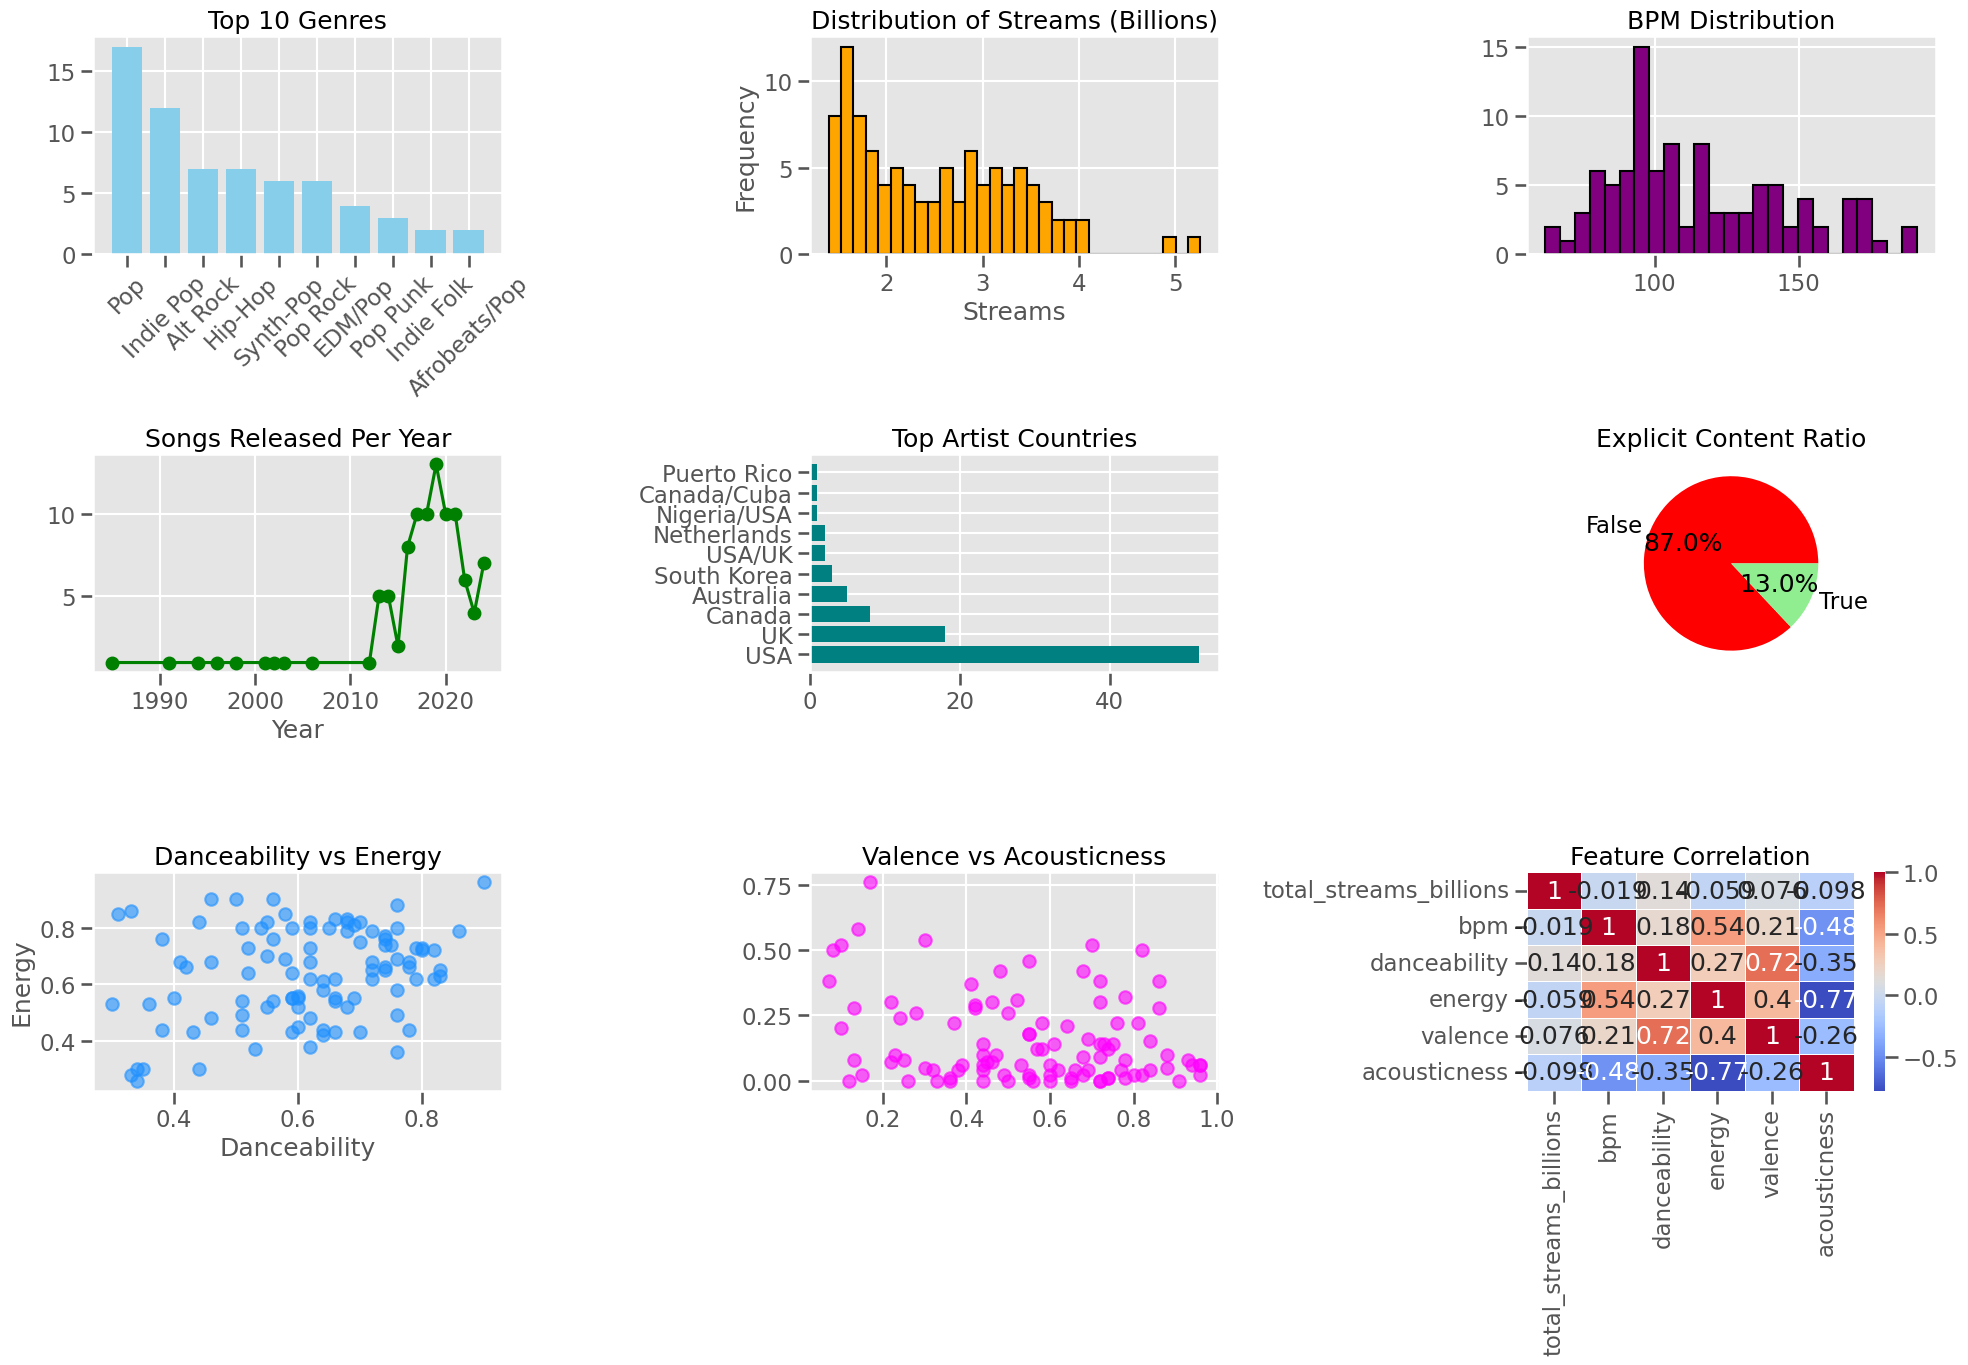

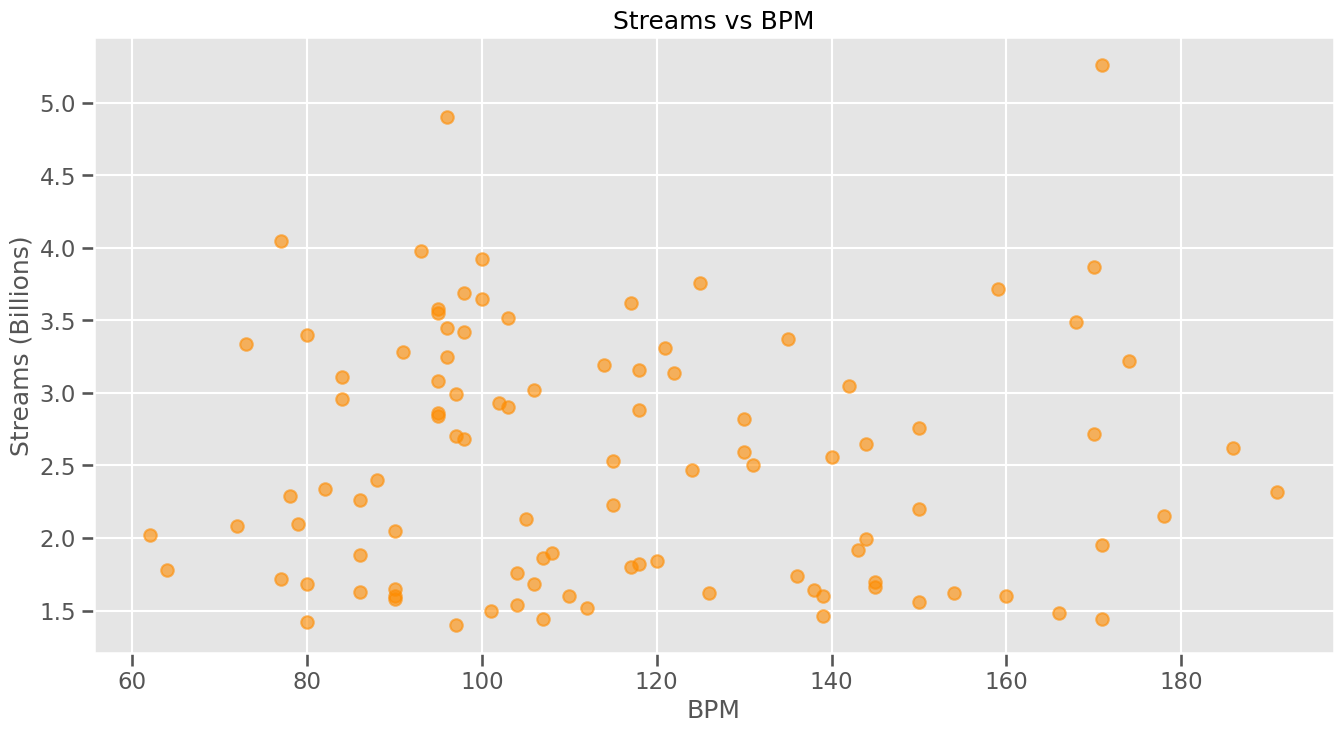

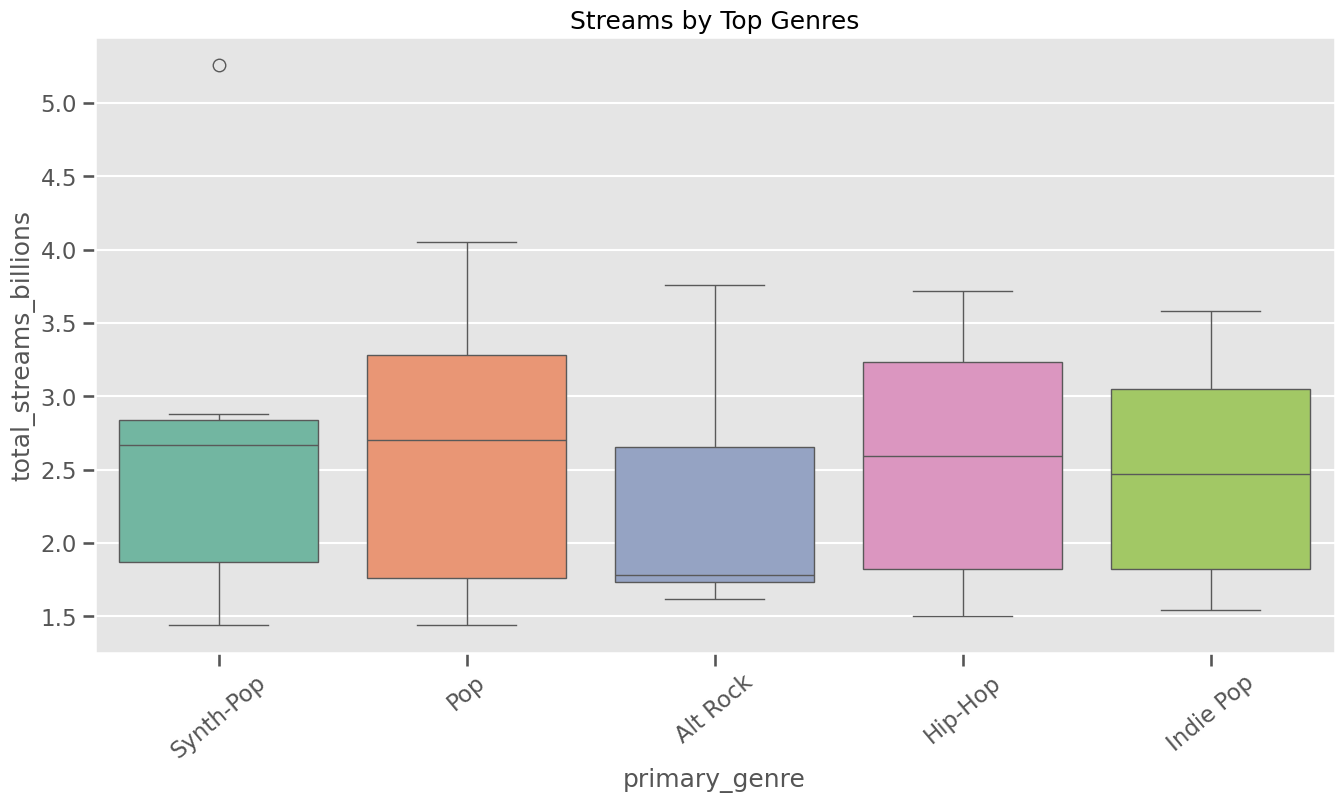

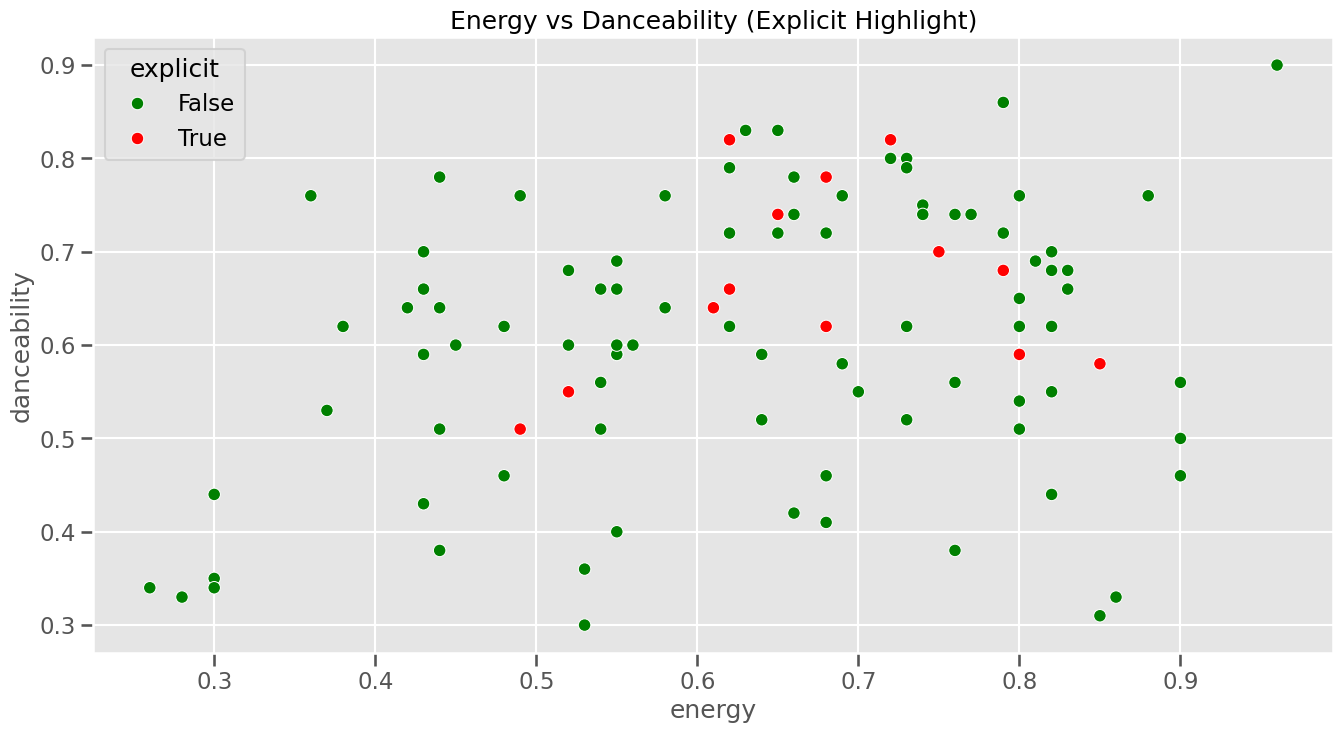

In [11]:
# ===============================
# Visualization for Music Dataset
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use("ggplot")
sns.set_context("talk")

# ===============================
# Basic Info
# ===============================
print(df.head())
print(df.describe())

# ===============================
# Figure Setup
# ===============================
plt.figure(figsize=(20, 14))

# 1. Top Genres Distribution
plt.subplot(3, 3, 1)
genre_counts = df['primary_genre'].value_counts().head(10)
plt.bar(genre_counts.index, genre_counts.values, color='skyblue')
plt.title("Top 10 Genres")
plt.xticks(rotation=45)

# 2. Streams Distribution
plt.subplot(3, 3, 2)
plt.hist(df['total_streams_billions'], bins=30, color='orange', edgecolor='black')
plt.title("Distribution of Streams (Billions)")
plt.xlabel("Streams")
plt.ylabel("Frequency")

# 3. BPM Distribution
plt.subplot(3, 3, 3)
plt.hist(df['bpm'], bins=25, color='purple', edgecolor='black')
plt.title("BPM Distribution")

# 4. Release Year Trend
plt.subplot(3, 3, 4)
year_counts = df['release_year'].value_counts().sort_index()
plt.plot(year_counts.index, year_counts.values, marker='o', color='green')
plt.title("Songs Released Per Year")
plt.xlabel("Year")

# 5. Artist Country Distribution
plt.subplot(3, 3, 5)
country_counts = df['artist_country'].value_counts().head(10)
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title("Top Artist Countries")

# 6. Explicit vs Non-Explicit
plt.subplot(3, 3, 6)
explicit_counts = df['explicit'].value_counts()
plt.pie(explicit_counts.values,
        labels=explicit_counts.index,
        autopct='%1.1f%%',
        colors=['red', 'lightgreen'])
plt.title("Explicit Content Ratio")

# 7. Danceability vs Energy
plt.subplot(3, 3, 7)
plt.scatter(df['danceability'], df['energy'],
            alpha=0.6,
            color='dodgerblue')
plt.title("Danceability vs Energy")
plt.xlabel("Danceability")
plt.ylabel("Energy")

# 8. Valence vs Acousticness
plt.subplot(3, 3, 8)
plt.scatter(df['valence'], df['acousticness'],
            alpha=0.6,
            color='magenta')
plt.title("Valence vs Acousticness")

# 9. Correlation Heatmap
plt.subplot(3, 3, 9)
corr = df[['total_streams_billions', 'bpm', 'danceability',
           'energy', 'valence', 'acousticness']].corr()
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)
plt.title("Feature Correlation")

plt.tight_layout()
plt.show()

# ===============================
# Additional Advanced Plots
# ===============================

plt.figure(figsize=(16, 8))

# Streams vs BPM
plt.scatter(df['bpm'], df['total_streams_billions'],
            color='darkorange', alpha=0.6)
plt.title("Streams vs BPM")
plt.xlabel("BPM")
plt.ylabel("Streams (Billions)")
plt.show()

plt.figure(figsize=(16, 8))

# Boxplot of Streams by Genre
top_genres = df['primary_genre'].value_counts().head(5).index
sns.boxplot(data=df[df['primary_genre'].isin(top_genres)],
            x='primary_genre',
            y='total_streams_billions',
            palette='Set2')
plt.title("Streams by Top Genres")
plt.xticks(rotation=40)
plt.show()

plt.figure(figsize=(16, 8))

# Energy vs Danceability colored by Explicit
sns.scatterplot(data=df,
                x='energy',
                y='danceability',
                hue='explicit',
                palette=['green', 'red'])
plt.title("Energy vs Danceability (Explicit Highlight)")
plt.show()

## Feature engineering

In [12]:
# Create binary target (Hit if streams > median)
df["target"] = (df["total_streams_billions"] > df["total_streams_billions"].median()).astype(int)


Logistic Regression
Accuracy: 0.9500
ROC-AUC: 1.0000

Decision Tree
Accuracy: 1.0000
ROC-AUC: 1.0000

Random Forest
Accuracy: 1.0000
ROC-AUC: 1.0000


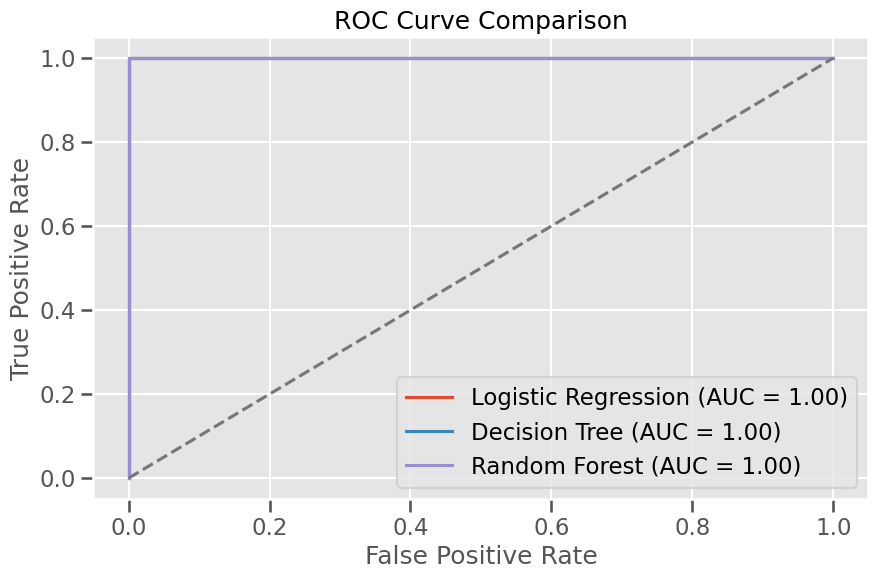

In [13]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# -----------------------------
# Create Target
# -----------------------------
df["target"] = (df["total_streams_billions"] > df["total_streams_billions"].median()).astype(int)

# Features & Target
X = df.drop(columns=["target", "song_title", "dataset_part"])
y = df["target"]

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# SAFE Encoding (Fix)
# -----------------------------
cat_cols = ["artist", "primary_genre", "artist_country", "explicit"]

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit ONLY on training data
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])

# Transform test safely (no crash now)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# -----------------------------
# Scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# -----------------------------
# Training + ROC Curve
# -----------------------------
plt.figure(figsize=(10,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC: {auc:.4f}")
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Plot ROC
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Thank you..pls upvote!!!!!!!